# Analyse

## Importations

In [1]:
%load_ext autoreload
%autoreload 2
from main import *

## Entrainement et affichage DDPG

In [2]:
ddpg_config = DDPGConfig()
ddpg = run_ddpg(ddpg_config)

ddpg.visualize_best()

  0%|          | 0/30000 [00:00<?, ?it/s]

## Entrainement et affichage TD3

In [3]:
td3_config = TD3Config()
td3 = run_td3(td3_config)
td3.visualize_best()

  0%|          | 0/30000 [00:00<?, ?it/s]

## Comparaison DDPG vs TD3

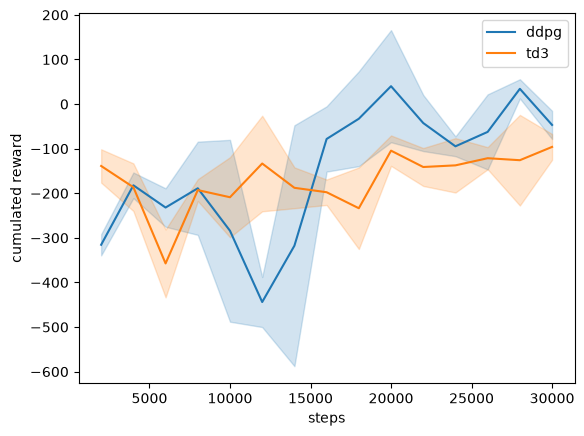

DDPG vs TD3 (final evaluation): t=3.63, p-value=0.002


In [4]:
plot_evaluations(ddpg=ddpg, td3=td3)

# The Welch t-test tells us whether the difference between the final
# evaluations is statistically significant (p-value < 0.05)
welch = stats.ttest_ind(
    ddpg.history[-1].rewards.numpy(), td3.history[-1].rewards.numpy(), equal_var=False
)
print(
    f"DDPG vs TD3 (final evaluation): t={welch.statistic:.2f}, p-value={welch.pvalue:.3f}"
)

In [ ]:
cfg = td3_config
print(cfg)

TD3Config(env_name='LunarLanderContinuous-v3', seed=1, max_steps=30000, n_envs=1, steps_per_update=1, learning_starts=1000, buffer_size=200000, batch_size=64, gamma=0.98, tau=0.05, action_noise=0.1, actor_hidden=(64, 64), critic_hidden=(64, 64), use_layer_norm=True, lr_actor=0.001, lr_critic=0.001, eval_interval=2000, n_eval_envs=10, policy_delay=2, target_noise=0.2, target_noise_clip=0.5)
